# Acero

In [1]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import matplotlib.pyplot as plt 

In [2]:
def get_last_second_amplitude(t, V):
    t = np.asarray(t)
    V = np.asarray(V)
        
    t_end = t[-1]
    t_start = t_end - 1.0
    
    mask = t >= t_start
    
    V_last_second = V[mask]
    
    if len(V_last_second) == 0:
        return 0.0
        
    amplitude = (np.max(V_last_second) - np.min(V_last_second)) / 2.0
    
    return amplitude

In [3]:
import glob

amplitudes = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line like before
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    # skiprows=2 ignores the first two metadata lines so it uses "Time (s),Voltage (V)" as headers
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply your function
    amp = get_last_second_amplitude(t, V)
    
    # 4. Save the amplitude to our array
    amplitudes.append(amp)

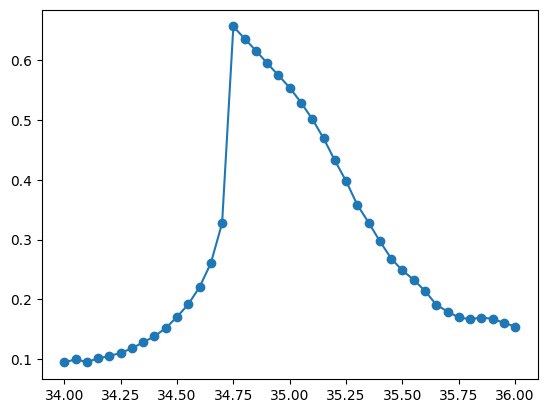

In [4]:
plt.plot(frequencies, amplitudes, marker='o') 

In [15]:
f_data = np.array(frequencies)
a_data = np.array(amplitudes)

<>:91: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:91: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\nysg\AppData\Local\Temp\ipykernel_15320\5905896.py:91: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Driving Frequency $\omega$')


=== FITTED PARAMETERS ===
w0 (Linear Res Freq) : 21.9895
alpha (Nonlinearity) : -9.6777e+01
zeta (Damping Ratio) : -1.5889e-02
F (Forcing Amp)      : 8.1207


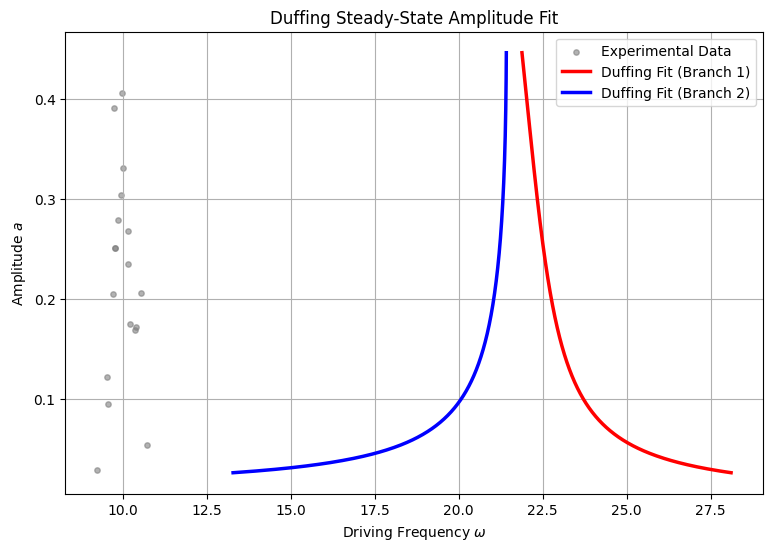

In [20]:
from scipy.optimize import least_squares

# 1. Load your data (Replace 'data.csv' with your file)
# Expects a CSV with columns 'w' (frequency) and 'a' (amplitude)
# df = pd.read_csv('data.csv')


# --- FOR DEMONSTRATION: GENERATING SYNTHETIC HARDENING DUFFING DATA ---
# (Remove this block when using your real data)
np.random.seed(42)
w0_true, alpha_true, zeta_true, F_true = 10.0, 0.5, 0.02, 1.5
a_synth = np.linspace(0.1, 10.0, 300)
w_synth = []
a_valid = []
for a in a_synth:
    A = a**2
    B = 4 * zeta_true**2 * w0_true**2 * a**2 - 2 * a * (w0_true**2 * a + 0.75 * alpha_true * a**3)
    C = (w0_true**2 * a + 0.75 * alpha_true * a**3)**2 - F_true**2
    disc = B**2 - 4*A*C
    if disc >= 0:
        x1, x2 = (-B + np.sqrt(disc)) / (2*A), (-B - np.sqrt(disc)) / (2*A)
        if x1 > 0: w_synth.append(np.sqrt(x1)); a_valid.append(a)
        if x2 > 0: w_synth.append(np.sqrt(x2)); a_valid.append(a)
w_data = np.array(w_synth) + np.random.normal(0, 0.05, len(w_synth))
a_data = np.array(a_valid) + np.random.normal(0, 0.05, len(a_valid))
# ----------------------------------------------------------------------

# 2. Define the Implicit Residual Function
def duffing_residual(params, w, a):
    w0, alpha, zeta, F = params
    
    # Equation: [(w0^2 - w^2)a + (3/4)*alpha*a^3]^2 + (2*zeta*w0*w*a)^2 - F^2 = 0
    term1 = (w0**2 - w**2) * a + 0.75 * alpha * a**3
    term2 = 2 * zeta * w0 * w * a
    
    residual = (term1**2 + term2**2) - F**2
    
    # Normalizing residual to prevent gradients from blowing up during fitting
    return residual / (w0**4) 

# 3. Initial Guesses
# You MUST provide a reasonably close initial guess for implicit fitting to converge.
# w0: ~Peak location in linear regime
# alpha: positive for hardening, >0 
# zeta: damping ratio (e.g., 0.01 for Q=50)
# F: forcing amplitude
initial_guess = [35.182, -96.622, 0.0046, 7.906]

# 4. Perform the Fit
# 'soft_l1' loss makes the fit robust to the sharp vertical jumps/outliers
res = least_squares(duffing_residual, initial_guess, args=(w_data, a_data), loss='soft_l1')
w0_opt, alpha_opt, zeta_opt, F_opt = res.x

print("=== FITTED PARAMETERS ===")
print(f"w0 (Linear Res Freq) : {w0_opt:.4f}")
print(f"alpha (Nonlinearity) : {alpha_opt:.4e}")
print(f"zeta (Damping Ratio) : {zeta_opt:.4e}")
print(f"F (Forcing Amp)      : {F_opt:.4f}")

# 5. Plot the Data vs the Fitted Implicit Curve
plt.figure(figsize=(9, 6))

# Plot experimental data
plt.scatter(w_data, a_data, s=15, alpha=0.6, color='gray', label='Experimental Data')

# To plot the fitted theoretical curve, we solve for w as a function of a
a_fit = np.linspace(min(a_data)*0.9, max(a_data)*1.1, 1000)
w_fit_branch1 = []
w_fit_branch2 = []

for a in a_fit:
    # Treat the Duffing eq as a quadratic equation in x = w^2
    # A*x^2 + B*x + C = 0
    A = a**2
    B = 4 * zeta_opt**2 * w0_opt**2 * a**2 - 2 * a * (w0_opt**2 * a + 0.75 * alpha_opt * a**3)
    C = (w0_opt**2 * a + 0.75 * alpha_opt * a**3)**2 - F_opt**2
    
    disc = B**2 - 4*A*C
    if disc >= 0:
        x1 = (-B + np.sqrt(disc)) / (2*A)
        x2 = (-B - np.sqrt(disc)) / (2*A)
        w_fit_branch1.append(np.sqrt(x1) if x1 > 0 else np.nan)
        w_fit_branch2.append(np.sqrt(x2) if x2 > 0 else np.nan)
    else:
        w_fit_branch1.append(np.nan)
        w_fit_branch2.append(np.nan)

plt.plot(w_fit_branch1, a_fit, 'r-', lw=2.5, label='Duffing Fit (Branch 1)')
plt.plot(w_fit_branch2, a_fit, 'b-', lw=2.5, label='Duffing Fit (Branch 2)')

plt.xlabel('Driving Frequency $\omega$')
plt.ylabel('Amplitude $a$')
plt.title('Duffing Steady-State Amplitude Fit')
plt.legend()
plt.grid(True)
plt.show()

<>:97: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:97: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\nysg\AppData\Local\Temp\ipykernel_15320\3914964781.py:97: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Frequency $\omega$')


=== PHYSICALLY CONSTRAINED PARAMETERS ===
w0    = 35.1736
alpha = -120.6237
zeta  = 6.1702e-08
F     = 7.6596


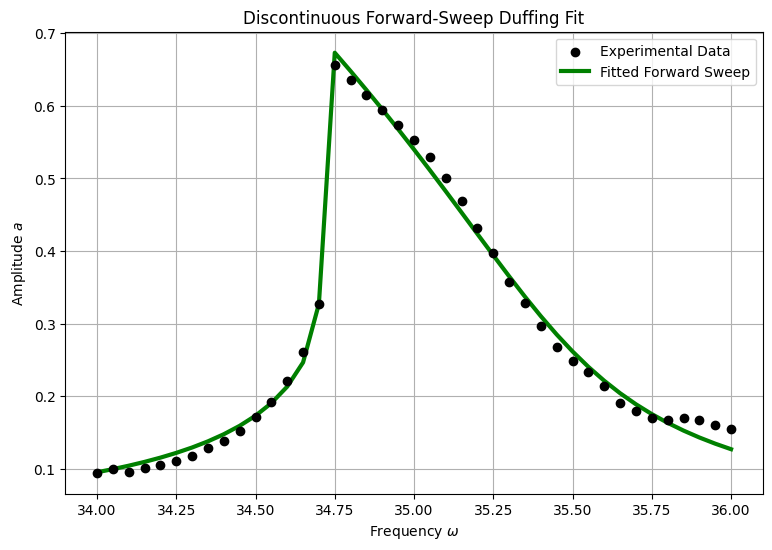

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- 1. YOUR DATA ---
w_data = np.array([34., 34.05, 34.1, 34.15, 34.2, 34.25, 34.3, 34.35, 34.4,
       34.45, 34.5, 34.55, 34.6, 34.65, 34.7, 34.75, 34.8, 34.85, 34.9,
       34.95, 35., 35.05, 35.1, 35.15, 35.2, 35.25, 35.3, 35.35, 35.4,
       35.45, 35.5, 35.55, 35.6, 35.65, 35.7, 35.75, 35.8, 35.85, 35.9,
       35.95, 36.])

a_data = np.array([0.0947, 0.1001, 0.0956, 0.1016, 0.1055, 0.1107, 0.1183,
       0.1285, 0.1384, 0.1521, 0.1709, 0.1918, 0.2207, 0.2605, 0.3273,
       0.6559, 0.6356, 0.6155, 0.5946, 0.5742, 0.5536, 0.5289, 0.5013,
       0.4693, 0.4322, 0.3977, 0.3578, 0.3284, 0.2972, 0.2684, 0.2484,
       0.2330, 0.2142, 0.1913, 0.1798, 0.1699, 0.1670, 0.1697, 0.1678,
       0.1609, 0.1547])

# --- 2. PHYSICS ENGINE ---
def get_stable_roots(w, w0, alpha, zeta, F):
    """Solves the cubic Duffing equation for a^2 and classifies stability."""
    # Coefficients for the cubic in x = a^2
    c3 = (9.0/16.0) * alpha**2
    c2 = (3.0/2.0) * alpha * (w0**2 - w**2)
    c1 = (w0**2 - w**2)**2 + 4 * zeta**2 * w0**2 * w**2
    c0 = -F**2
    
    roots = np.roots([c3, c2, c1, c0])
    # Filter for real, positive roots
    real_roots = [r.real for r in roots if np.isclose(r.imag, 0, atol=1e-5) and r.real > 0]
    
    stable_roots = []
    for x in real_roots:
        # Evaluate stability condition: d(F^2)/d(a^2) > 0
        g_prime = (w0**2 - w**2 + 0.75*alpha*x)**2 + 1.5*alpha*x*(w0**2 - w**2 + 0.75*alpha*x) + 4*zeta**2*w0**2*w**2
        if g_prime > 0:
            stable_roots.append(x)
            
    # Fallback if numerical issues cause all roots to vanish slightly prematurely
    if not stable_roots:
        stable_roots = real_roots if real_roots else [1e-9]
        
    return stable_roots

def forward_sweep(w_array, w0, alpha, zeta, F):
    """Simulates a forward frequency sweep, jumping at bifurcation points."""
    a_sim = []
    curr_x = None
    
    for w in w_array:
        stable_roots = get_stable_roots(w, w0, alpha, zeta, F)
        
        if curr_x is None:
            # Start of sweep: lock onto the lowest amplitude stable branch
            curr_x = min(stable_roots)
        else:
            # Continue on current branch: pick the root closest to current state.
            # If the branch undergoes saddle-node bifurcation and disappears, 
            # this automatically "jumps" to the remaining stable root.
            curr_x = min(stable_roots, key=lambda rx: abs(rx - curr_x))
            
        a_sim.append(np.sqrt(curr_x))
        
    return np.array(a_sim)

# --- 3. OPTIMIZATION ---
def objective(params):
    w0, alpha, zeta, F = params
    
    # Strictly enforce physical boundaries
    if zeta <= 0 or w0 <= 0 or F <= 0:
        return 1e9
        
    a_sim = forward_sweep(w_data, w0, alpha, zeta, F)
    return np.sum((a_sim - a_data)**2)  # SSE

# Initial guess from the previous implicit fit
p0 = [35.18, -96.6, 0.0046, 7.9]

# Use derivative-free Nelder-Mead due to the discontinuous jump in the function
res = minimize(objective, p0, method='Nelder-Mead', options={'maxiter': 3000})

w0_opt, alpha_opt, zeta_opt, F_opt = res.x
print("=== PHYSICALLY CONSTRAINED PARAMETERS ===")
print(f"w0    = {w0_opt:.4f}")
print(f"alpha = {alpha_opt:.4f}")
print(f"zeta  = {zeta_opt:.4e}")
print(f"F     = {F_opt:.4f}")

# --- 4. PLOTTING ---
a_fit_sweep = forward_sweep(w_data, w0_opt, alpha_opt, zeta_opt, F_opt)

plt.figure(figsize=(9, 6))
plt.scatter(w_data, a_data, color='black', label='Experimental Data', zorder=5)
plt.plot(w_data, a_fit_sweep, 'g-', lw=3, label='Fitted Forward Sweep')

plt.xlabel('Frequency $\omega$')
plt.ylabel('Amplitude $a$')
plt.title('Discontinuous Forward-Sweep Duffing Fit')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
data = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_131512.csv', delimiter=',',skiprows=3)
data2 = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_130601.csv', delimiter=',',skiprows=3)

(0.0, 2.0)

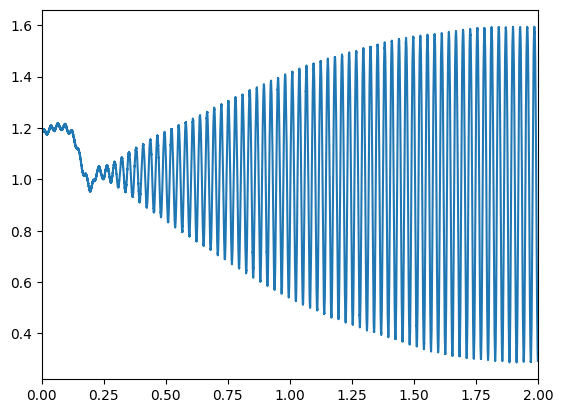

In [69]:
plt.plot(data[:,0], data[:,1])
plt.xlim(0,2)

Data points available for fit (M): 1180373
Calculated Time Constant (tau): 0.1089
Settling time (approx 5*tau): 0.5443


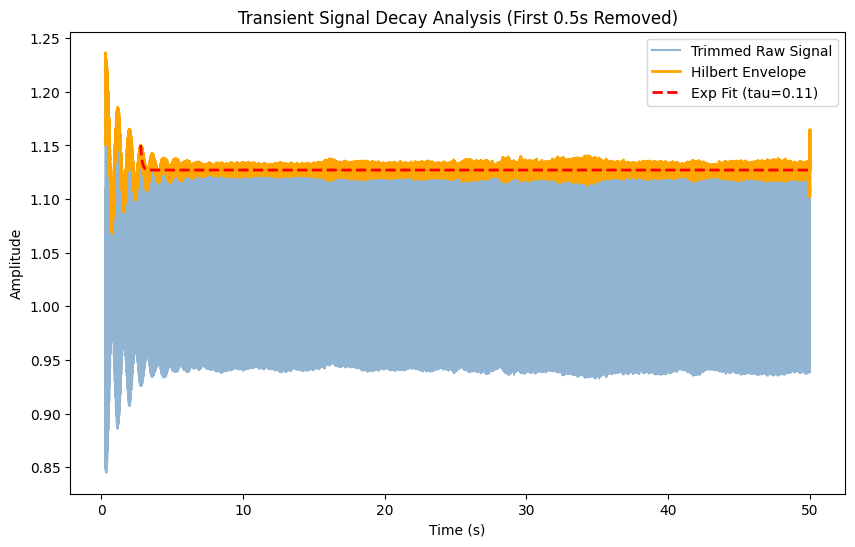

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.optimize import curve_fit

# Assuming 't' and 'y' are your raw numpy arrays from the dataset
t = data2[:, 0]
y = data2[:, 1]

# --- NEW STEP: Trim the first 0.5s ---
trim_mask = t >= 0.3
t_clean = t[trim_mask]
y_clean = y[trim_mask]

# 1. Remove DC Offset (Crucial before Hilbert transform)
y_centered = y_clean - np.mean(y_clean)

# 2. Extract the envelope using the Hilbert Transform
analytic_signal = hilbert(y_centered)
envelope = np.abs(analytic_signal)
# 3. Isolate the decay phase (Safely)
# The Hilbert transform creates false spikes at the boundaries. 
# We define a margin (e.g., 5% of the data length) to ignore these edges.
margin = int(len(envelope) * 0.05)

# Find the peak ONLY within the safe middle region
# Add the margin back to get the correct index relative to the full array
peak_idx = np.argmax(envelope[margin:-margin]) + margin

t_decay = t_clean[peak_idx:]
envelope_decay = envelope[peak_idx:]

# Quick debug print to ensure you have enough data points
print(f"Data points available for fit (M): {len(t_decay)}")

# 4. Define the exponential decay function
def exp_decay(t, A, tau, C):
    t0 = t_decay[0] # Shift time to start at 0 for the fit
    return A * np.exp(-(t - t0) / tau) + C

# 5. Perform the curve fit
# Initial guesses: [Amplitude, tau, Offset]
initial_guess = [np.max(envelope_decay) - np.min(envelope_decay), 1.0, np.min(envelope_decay)]

popt, pcov = curve_fit(exp_decay, t_decay, envelope_decay, p0=initial_guess)
A_fit, tau_fit, C_fit = popt

print(f"Calculated Time Constant (tau): {tau_fit:.4f}")
print(f"Settling time (approx 5*tau): {5 * tau_fit:.4f}")

# 6. Visualize the results
plt.figure(figsize=(10, 6))
# Plot the cleaned raw data (adding mean back for visualization if desired)
plt.plot(t_clean, y_clean, label='Trimmed Raw Signal', color='steelblue', alpha=0.6)

# Plot the envelope (adding the mean back so it aligns visually with raw data)
plt.plot(t_clean, envelope + np.mean(y_clean), label='Hilbert Envelope', color='orange', linewidth=2)

# Plot the fit
plt.plot(t_decay, exp_decay(t_decay, *popt) + np.mean(y_clean), label=f'Exp Fit (tau={tau_fit:.2f})', color='red', linestyle='--', linewidth=2)

plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Transient Signal Decay Analysis (First 0.5s Removed)')
plt.show()

In [77]:
import glob
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from scipy.optimize import curve_fit

def get_time_constant(t, y):
    """
    Extracts the time constant (tau) from a transient signal 
    using the Hilbert transform and an exponential fit.
    """
    # 1. Trim the first 0.5s of data
    trim_mask = t >= 0.5
    t_clean = t[trim_mask]
    y_clean = y[trim_mask]
    
    # 2. Remove DC Offset
    y_centered = y_clean - np.mean(y_clean)
    
    # 3. Extract envelope
    analytic_signal = hilbert(y_centered)
    envelope = np.abs(analytic_signal)
    
    # 4. Isolate decay safely (ignore 5% edges to avoid Hilbert artifacts)
    margin = int(len(envelope) * 0.05)
    
    # Ensure there is enough data to apply the margin
    if len(envelope) <= 2 * margin:
        return np.nan 
        
    peak_idx = np.argmax(envelope[margin:-margin]) + margin
    t_decay = t_clean[peak_idx:]
    envelope_decay = envelope[peak_idx:]
    
    # 5. Define decay function locally
    def exp_decay(t_data, A, tau, C):
        t0 = t_decay[0] 
        return A * np.exp(-(t_data - t0) / tau) + C
    
    # 6. Fit the curve
    initial_guess = [np.max(envelope_decay) - np.min(envelope_decay), 1.0, np.min(envelope_decay)]
    
    try:
        # maxfev increases the allowed iterations to help tough fits converge
        popt, pcov = curve_fit(exp_decay, t_decay, envelope_decay, p0=initial_guess, maxfev=2000)
        tau_fit = popt[1] # The second parameter is tau
        return tau_fit
    except RuntimeError:
        # If the curve_fit fails to converge, return NaN instead of crashing the loop
        return np.nan


# --- Main Loop Execution ---

taus = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply the new time constant function
    tau = get_time_constant(t, V)
    
    # 4. Save tau to our array
    taus.append(tau)
    
    # Optional: Print progress so you know it's working
    print(f"Processed file: {file_path} | Freq: {freq} Hz | Tau: {tau:.4f}")

# At the end, you can easily load this into a new DataFrame for analysis
results_df = pd.DataFrame({
    'Frequency (Hz)': frequencies,
    'Tau (s)': taus
})

Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130601.csv | Freq: 34.0 Hz | Tau: 0.1154
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130647.csv | Freq: 34.05 Hz | Tau: 0.0790
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130726.csv | Freq: 34.1 Hz | Tau: 3.1724
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130759.csv | Freq: 34.15 Hz | Tau: 0.1006
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130831.csv | Freq: 34.2 Hz | Tau: 0.6071
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130859.csv | Freq: 34.25 Hz | Tau: 0.0944
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130922.csv | Freq: 34.3 Hz | Tau: 0.1043
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130947.csv | Freq: 34.35 Hz | Tau: 0.1783


C:\Users\nysg\AppData\Local\Temp\ipykernel_15320\2916163089.py:38: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-(t_data - t0) / tau) + C


Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131012.csv | Freq: 34.4 Hz | Tau: 0.1528
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131036.csv | Freq: 34.45 Hz | Tau: 0.1568
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131057.csv | Freq: 34.5 Hz | Tau: 0.1461
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131121.csv | Freq: 34.55 Hz | Tau: 0.2039
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131146.csv | Freq: 34.6 Hz | Tau: 0.2590
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131210.csv | Freq: 34.65 Hz | Tau: 0.3439
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131233.csv | Freq: 34.7 Hz | Tau: 0.6418
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131307.csv | Freq: 34.75 Hz | Tau: 0.6887
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131336.csv | Freq: 34.8 Hz | Tau: 0.5744
Processed file: data_cle

(34.25, 35.25)

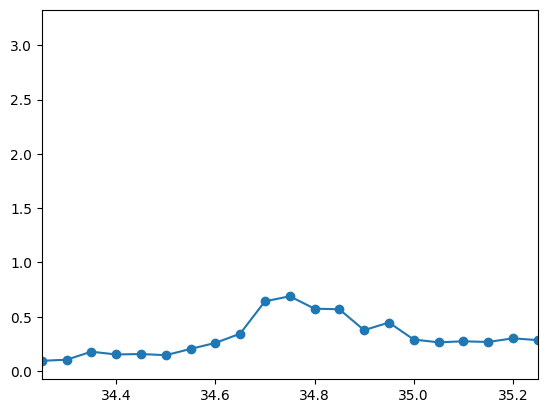

In [79]:
plt.plot(frequencies, taus, marker='o', label='Amplitude')
plt.xlim(34.25,35.25)